<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/LLM/LLM01/BERT_pretrained_model_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 6. 프로젝트 : mini BERT 만들기

## 라이브러리 버전을 확인해 봅니다.
---
사용할 라이브러리 버전을 둘러봅시다.

In [1]:
import torch
import numpy
import pandas
import matplotlib
import json
import re

print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.11.0+cu128
2.1.3
2.2.3
3.10.0
2.0.9
2.2.1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/Aiffel_EPA/bert_pretrain'
DATA_DIR  = f'{BASE_DIR}/data'
MODEL_DIR = f'{BASE_DIR}/models'

!mkdir -p "{DATA_DIR}" "{MODEL_DIR}"
!wget -nc https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -P "{DATA_DIR}"
!unzip -n "{DATA_DIR}/kowiki.txt.zip" -d "{DATA_DIR}"
!ls -l "{DATA_DIR}"

Mounted at /content/drive
File ‘/content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip’ already there; not retrieving.

Archive:  /content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip
total 2374258
-rw------- 1 root root  136533363 Sep 16 02:36 bert_pre_train.json
-rw------- 1 root root 1385037418 Sep 16 02:52 bert_pre_train_ko8000_c75266dc6d10_seq128_mask0.15_v1.json
-rw------- 1 root root  666544979 Jul 11  2020 kowiki.txt
-rw------- 1 root root  243123354 Jun 23  2021 kowiki.txt.zip


In [3]:
!pip install -q sentencepiece tqdm

In [4]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 777
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

# 여러 셀이 공유하는 장치 설정 (GPU 런타임이면 cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

2.11.0+cu128
device: cuda


## 1. Tokenizer 준비
---
SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요.

이를 위해 한글 나무 위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델을 만들어 보세요. BERT에 사용되는 주요 특수문자가 vocab에 포함되어야 합니다.

In [5]:
corpus_file = f'{DATA_DIR}/kowiki.txt'
prefix = f'{MODEL_DIR}/ko_8000'
vocab_size = 8000

if not os.path.exists(f'{prefix}.model'):   # 드라이브에 이미 있으면 다시 만들지 않는다
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}"
        " --model_type=bpe --max_sentence_length=999999"
        " --input_sentence_size=1000000 --shuffle_input_sentence=true"
        " --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK]"
        " --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS]"
        " --user_defined_symbols=[SEP],[CLS],[MASK]")
print(os.listdir(MODEL_DIR))

['ko_8000_guide', 'ko_32000.model', 'ko_32000.vocab', 'ko_8000.model', 'ko_8000.vocab', 'mini_bert_submission_20260916_025254_967467', 'bert_pre_train_epoch_1.pt', 'bert_pre_train_epoch_2.pt', 'bert_pre_train_epoch_3.pt', 'bert_pre_train_epoch_4.pt', 'bert_pre_train_epoch_5.pt', 'bert_pre_train_epoch_6.pt', 'bert_pre_train_epoch_7.pt', 'bert_pre_train_epoch_8.pt', 'bert_pre_train_epoch_9.pt', 'bert_pre_train_epoch_10.pt']


In [6]:
data_dir, model_dir = DATA_DIR, MODEL_DIR

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_8000.model")

True

토크나이저가 잘 만들어졌는지 확인해 봅시다. 어떤 토큰이 만들어졌는지, 토크나이징 결과가 어떻게 나오는지 살펴볼까요?

In [7]:
# 토크나이저 확인
print("어휘 수:", len(vocab))
print(vocab.encode_as_pieces("이것은 토크나이저 확인 문장입니다."))


어휘 수: 8007
['▁이것은', '▁토', '크', '나이', '저', '▁확인', '▁문', '장', '입', '니다', '.']


## 3. 데이터 전처리

## (1) MASK 생성
BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요. 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용하세요.

15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다. Subword 기반으로 토크나이징을 했을 때 `_대, [MASK], 민국`이라고 가운데를 마스킹 했을 경우 해당 `[MASK]`가 '한'일 거라는 건 너무 쉽게 맞출 수 있습니다. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.

그래서 Masked LM 태스크를 구성할 땐 **띄어쓰기 단위로 한꺼번에 마스킹**해 주는 것이 좋습니다. 다음과 같이 처리합니다.

In [8]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """어절 단위로 약 15%를 선택하고 80/10/10 규칙을 적용합니다."""
    cand_idx = []
    for i, token in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        if cand_idx and not token.startswith("▁"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            original_token = tokens[index]
            if dice < 0.8:
                tokens[index] = "[MASK]"
            elif dice < 0.9:
                tokens[index] = original_token
            else:
                tokens[index] = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": original_token})

    mask_lms.sort(key=lambda item: item["index"])
    return tokens, [item["index"] for item in mask_lms], [item["label"] for item in mask_lms]


BERT 원본의 NSP 는 NotNext 문장을 **다른 문서에서 무작위로** 뽑습니다. 여기서는 구현이 간단하도록 짝지은 두 문장의 **순서를 뒤바꾸는** 것으로 NotNext 를 만들겠습니다. 이 변형은 앞 레슨 8절에서 본 ALBERT 의 SOP(Sentence Order Prediction)와 같은 방식이라, 모델은 '이어지는 문장인가' 보다 '순서가 맞는가' 를 배우게 됩니다.

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해 보겠습니다.

token A의 길이가 `max_seq`보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거합니다.

In [9]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

## 3. 데이터 전처리 (2) NSP pair 생성  
BERT의 pretrain task인 NSP는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 TRUE와 FALSE를 지정해 주세요.

두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.

MLM과 NSP는 동시에 학습된다는 것을 염두에 두고 학습 데이터를 구성해 보세요.

In [10]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

## (3) 데이터셋 완성

이제 우리가 다루어야 할 `kowiki.txt`에 대해 본격적으로 들여다보겠습니다.

In [11]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

기존 JSON 데이터셋을 사용합니다. 새 데이터셋이 필요하면 위의 `make_pretrain_data()`를 호출해 생성할 수 있습니다.


아래에서 JSON 경로를 확인한 뒤, `load_pre_train_data()`로 128,000건을 Colab 로컬 디스크의 memmap 배열에 읽습니다.


만들어진 json 파일을 라인 단위로 읽어 들여 `np.memmap`에 로딩해 봅시다.

In [12]:
from pathlib import Path

pretrain_json_path = (
    "/content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/"
    "bert_pre_train_ko8000_c75266dc6d10_seq128_mask0.15_v1.json"
)

assert Path(pretrain_json_path).is_file(), (
    f"파일을 찾을 수 없습니다: {pretrain_json_path}"
)

print(pretrain_json_path)

/content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/bert_pre_train_ko8000_c75266dc6d10_seq128_mask0.15_v1.json


## 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
---
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성하였습니다.

In [13]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir='/content/memmap'):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일을 둘 폴더 (Colab 로컬 디스크)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    os.makedirs(memmap_dir, exist_ok=True)
    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=f'{memmap_dir}/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

## 학습 데이터 수를 2배수로 증가

```
원본 텍스트: kowiki.txt
    ↓
최대 100만 개 입력 줄을 샘플링해 토크나이저 학습
    ↓
보캡 생성: 일반 토큰 8,000개 + 특수 토큰 7개
    ↓
이 토크나이저로 원본을 토큰으로 나누고
MLM 마스킹·문장 쌍을 만들어 JSON에 저장
    ↓
JSON에서 count=256000개 예제를 읽음
    ↓
그 예제들로 BERT 학습

```

보캡 크기: 모델이 사용할 수 있는 토큰의 종류 수  
학습 예제 수: 그 토큰들로 구성된 데이터를 얼마나 학습할지  


In [14]:
import tempfile

memmap_dir = tempfile.mkdtemp(
    prefix="bert_memmap_",
    dir="/content"
)

pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab,
    pretrain_json_path,
    n_seq=128,
    count=256000,
    memmap_dir=memmap_dir,
)

print("데이터 로딩 완료")

  0%|          | 0/256000 [00:00<?, ?it/s]

data load early stop 256000 256000
데이터 로딩 완료


## 4. BERT 모델 구현

우선 몇 가지 유틸리티 함수를 정의하겠습니다.

In [15]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [16]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [17]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. BERT 는 가중치를 표준편차 0.02 의 절단 정규분포로 초기화합니다. 아래 임베딩 클래스에서 `nn.init.trunc_normal_(…, std=0.02)` 로 직접 적용합니다. 아래는 Token Embedding의 구현입니다.

In [18]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


Position Embedding 레이어는 다음과 같습니다.

Transformer가 사인 함수와 코사인 함수를 이용한 Positional Encoding으로 토큰의 위치를 고정된 식으로 표현했던 것과 달리,  
BERT에서는 Position Embedding을 사용합니다.  

 Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.

In [19]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.

In [20]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [21]:
# 앞 절의 Transformer 와 같은 Multi-Head Attention 입니다. attn_mask 가 head 축으로 브로드캐스트되는 부분을 확인하세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.

In [22]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [23]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


+ Token Embedding
+ Position Embedding
+ Segment Embedding  

BERT의 입력은 다음 세 가지 Embedding(임베딩)을 더해서 만듭니다.

| 임베딩 | 알려주는 정보 | 예시 |
| --- | --- | --- |
| Token Embedding(토큰 임베딩) | 어떤 토큰인가? | 나는, 밥을, [CLS] |
| Position Embedding(위치 임베딩) | 문장에서 몇 번째 위치인가? | 0, 1, 2, 3… |
| Segment Embedding(구간 임베딩) | 문장 A와 문장 B 중 어디에 속하는가? | 문장 A=0, 문장 B=1 |



In [24]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        # 3개의 임배딩을 더 한다.
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.

In [25]:
# Pooled Output(NSP 분류 헤드) 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)

print("슝=3")

슝=3


In [26]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments) #bert 클래스 호출


        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


1차 학습에서는 예제의 값을 그대로 사용했다. 파라미터 크기가 2M이 나와 목적이었던 1M크기에 맞추기 어려웠다.  

1M크기로 맞추기 위해
1) d_model을 64로 조정 - 백터 크기를 반으로 축소
2) n_head 동결 - 멀티 헤드 어텐션이 중요한 기술이라고 하니 이것은 유지해보고 싶음
3) d_head를 32로 조정 - 머리 갯수는 유지하는 대신 머리 크기는 반으로 줄임
4) d_ff를 512로 축소 - FFN의 백터 크기 축소한다.

즉 전체 구조는 기존처럼 유지하되, 그 속의 백터 크기를 축소 시켜 1M으로 경량화 하도록 한다.

In [27]:
# 1차 예제 기준 실행 - 2M 크기 모델 탄생
# 2차 일부 값 조정 후 실행
# 멀티헤드 어ㅌ
config = Config({
    "d_model": 64, "n_head": 4, "d_head": 32, "dropout": 0.1, "d_ff": 512,
    "layernorm_epsilon": 0.001, "n_layer": 3, "n_seq": 256,
    "n_vocab": 5000, "i_pad": 0,
})


## 6. pretrain 진행
---


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 cosine 형태로 감소하는 스케줄을 적용합니다.


loss 는 `nn.CrossEntropyLoss` 를 씁니다.  

 NSP 는 문장 쌍당 하나의 2-class 분류이고, MLM 은 `ignore_index=0` 으로 마스크되지 않은 위치(라벨 0)를 제외해 마스크 위치의 평균만 계산합니다.   

 정확도도 학습 루프 안에서 마스크 위치만 세어 구합니다.

In [28]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 계산하고 optimizer 에 적용
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr

print("슝=3")

슝=3


이제 모델을 실제로 빌드해 봅시다.

In [29]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [30]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
config.n_vocab = len(vocab)
config.i_pad = vocab.pad_id()    # 0
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)], dtypes=[torch.long, torch.long])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 64]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 64]             512,448
│    └─PositionEmbedding: 2-2                                [10, 128, 64]             --
│    │    └─Embedding: 3-1                                   [10, 128, 64]             8,192
│    └─Embedding: 2-3                                        [10, 128, 64]             128
│    └─LayerNorm: 2-4                                        [10, 128, 64]             128
│    └─Dropout: 2-5                                          [10, 128, 64]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 64]           

2차 시도에서 0.8M이 나왔다.
3차 시도를 할 기회가 있다면 FFN을 기존 1024로 바꿔서 다시 해보고 싶다.

사실 가장 쉬운 방법은 보캡을 4천으로 맞춰버리면 될거같다.

In [31]:
epochs = 10
batch_size = 64

# optimizer + learning rate schedule
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)   # lr 은 스케줄러가 매 step 정한다
learning_rate_scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=max(100, train_steps // 10), max_lr=2.5e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

train_steps: 40000


In [32]:
from tqdm.auto import tqdm

pre_train_inputs = [
    torch.as_tensor(x, dtype=torch.long, device=device)
    for x in pre_train_inputs
]
pre_train_labels = [
    torch.as_tensor(x, dtype=torch.long, device=device)
    for x in pre_train_labels
]

train_dataset = TensorDataset(
    pre_train_inputs[0],
    pre_train_inputs[1],
    pre_train_labels[0],
    pre_train_labels[1],
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

pre_train_model.to(device)

history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
}

for epoch in range(epochs):
    pre_train_model.train()

    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    pbar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{epochs}",
        unit="batch",
    )


    for batch in pbar:
        (
            enc_tokens_batch,
            segments_batch,
            labels_nsp_batch,
            labels_mlm_batch,
        ) = batch

        optimizer.zero_grad()

        #pre_train_model 클래스 호출
        logits_nsp, logits_mlm = pre_train_model(
            enc_tokens_batch,
            segments_batch,
        )

        # 손실 계산
        loss_nsp = loss_fn_nsp(
            logits_nsp,
            labels_nsp_batch,
        )
        loss_mlm = loss_fn_mlm(
            logits_mlm.reshape(-1, logits_mlm.shape[-1]),
            labels_mlm_batch.reshape(-1),
        )
        total_loss_batch = loss_nsp + loss_mlm

        # 역전파 및 가중치 갱신
        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()

        # 정확도 계산
        with torch.no_grad():
            nsp_acc = (
                logits_nsp.argmax(dim=-1) == labels_nsp_batch
            ).float().mean()

            mlm_mask = labels_mlm_batch != 0
            mlm_correct = (
                logits_mlm.argmax(dim=-1) == labels_mlm_batch
            ) & mlm_mask

            mlm_acc = (
                mlm_correct.float().sum()
                / mlm_mask.float().sum().clamp(min=1)
            )

        # 배치 결과를 한 번씩 누적
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

        # 현재 배치 상태 표시
        pbar.set_postfix(
            loss=f"{total_loss_batch.item():.4f}",
            nsp_acc=f"{nsp_acc.item():.1%}",
            mlm_acc=f"{mlm_acc.item():.1%}",
            refresh=False,
        )

    # 여기부터는 Epoch마다 한 번 실행
    num_batches = len(train_dataloader)

    history["nsp_loss"].append(total_nsp_loss / num_batches)
    history["mlm_loss"].append(total_mlm_loss / num_batches)
    history["nsp_acc"].append(total_nsp_acc / num_batches)
    history["mlm_acc"].append(total_mlm_acc / num_batches)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {total_loss / num_batches:.4f} | "
        f"NSP Loss: {history['nsp_loss'][-1]:.4f} | "
        f"MLM Loss: {history['mlm_loss'][-1]:.4f} | "
        f"NSP Acc: {history['nsp_acc'][-1]:.1%} | "
        f"MLM Acc: {history['mlm_acc'][-1]:.1%}"
    )

    torch.save(
        pre_train_model.state_dict(),
        f"{MODEL_DIR}/bert_pre_train_epoch_{epoch + 1}.pt",
    )

Epoch 1/10:   0%|          | 0/4000 [00:00<?, ?batch/s]

Epoch 1/10 | Loss: 8.3242 | NSP Loss: 0.5965 | MLM Loss: 7.7277 | NSP Acc: 61.4% | MLM Acc: 2.6%


Epoch 2/10:   0%|          | 0/4000 [00:00<?, ?batch/s]

Epoch 2/10 | Loss: 7.9247 | NSP Loss: 0.5667 | MLM Loss: 7.3580 | NSP Acc: 61.5% | MLM Acc: 3.1%


Epoch 3/10:   0%|          | 0/4000 [00:00<?, ?batch/s]

...

Epoch 8/10 | Loss: 6.7421 | NSP Loss: 0.5142 | MLM Loss: 6.2279 | NSP Acc: 66.4% | MLM Acc: 11.6%


Epoch 9/10:   0%|          | 0/4000 [00:00<?, ?batch/s]

Epoch 9/10 | Loss: 6.6721 | NSP Loss: 0.5129 | MLM Loss: 6.1592 | NSP Acc: 66.3% | MLM Acc: 11.9%


Epoch 10/10:   0%|          | 0/4000 [00:00<?, ?batch/s]

Epoch 10/10 | Loss: 6.6478 | NSP Loss: 0.5118 | MLM Loss: 6.1360 | NSP Acc: 66.5% | MLM Acc: 12.0%


## 7. 프로젝트 결과
---
학습된 모델과 학습과정을 시각화해 보세요. NSP와 MLM의 loss가 안정적으로 수렴하나요? 모델이 작기 때문에 loss가 잘 수렴하지 않을 수도 있어요.

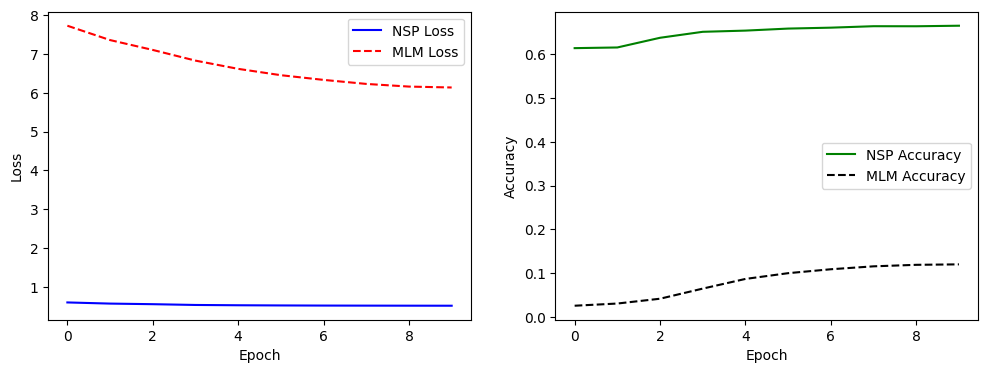

In [33]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 1차 예제의 설정값 사용 (보캡8000 - 파라미터 2M)


```
config = Config({
    "d_model": 128, "n_head": 4, "d_head": 64, "dropout": 0.1, "d_ff": 1024,
    "layernorm_epsilon": 0.001, "n_layer": 3, "n_seq": 256,
    "n_vocab": 5000, "i_pad": 0,
})
```


```
==============================================================================================================
Layer (type:depth-idx)                                       Output Shape              Param #
==============================================================================================================
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]            395,776
│    │    └─EncoderLayer: 3-3                                [10, 128, 128]            395,776
│    │    └─EncoderLayer: 3-4                                [10, 128, 128]            395,776
│    └─SharedEmbedding: 2-7                                  [10, 128, 8007]           (recursive)
├─PooledOutput: 1-2                                          [10, 2]                   --
│    └─Linear: 2-8                                           [10, 128]                 16,512
│    └─Linear: 2-9                                           [10, 2]                   256
==============================================================================================================
Total params: 2,245,888
Trainable params: 2,245,888
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.64
==============================================================================================================
Input size (MB): 0.02
Forward/backward pass size (MB): 158.02
Params size (MB): 8.98
Estimated Total Size (MB): 167.03
==============================================================================================================
```


  

   ## 1M 파라미터로 만드려면?
 * 현 모델은 약 2M의 파라미터를 갖고있는 BERT 모델이다. 파라미터를 반으로 줄이려면 다음과 같은 하이퍼파라미터들을 수정하면 조정이 가능 할 것이라는 생각으로 2회차 학습을 시작한다.


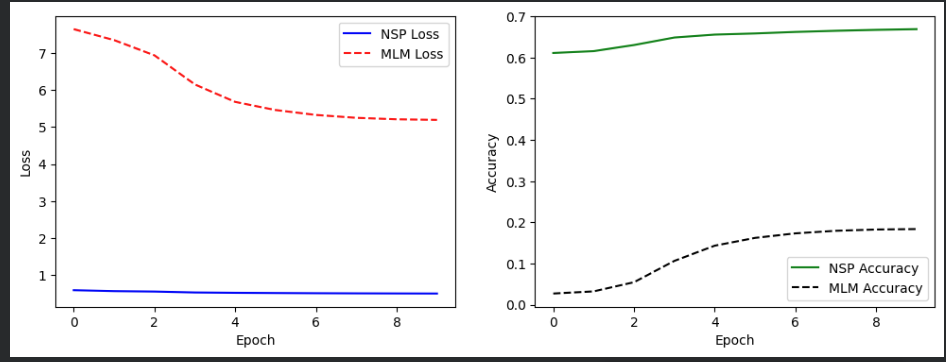  

  2M 모델 기준) 후반부에는 개선 폭이 작아지면서 정체괸다.

| 지표 | 처음 → 마지막 | 의미 |
|---|---|---|
| NSP Loss(손실) | 0.60 → 0.51 | 문장 관계를 판단하는 오류가 감소 |
| MLM Loss(손실) | 7.6 → 5.2 | 원래 토큰에 부여하는 확률이 개선 |
| NSP Accuracy(정확도) | 61% → 67% | 문장 관계 판단 능력이 조금 향상 |
| MLM Accuracy(정확도) | 3% → 18% | 예측 대상 토큰을 맞히는 비율이 증가 |

---

수렴을 하고 있는 것으로 볼 수 있다. 개선폭이 작아지는 것은 과적합 징후가 아닐 수도 있다.

현재 코드에서는 Learning rate(학습률)를 처음에 올린 뒤, cosine 방식으로 점차 낮춘다.  

 마지막에는 학습률이 거의 0에 가까워져 가중치 변화도 작아진다. 따라서 에포크 당 개선되는  loss와 정확도도 함께 줄어들 것이다.

 향후 학습에서는 발리데이션 셋을 적용해 얼리스탑을 통한 과적합 징후가 나올때까지 에포크를 늘릴 필요가 있다.

 ---

 # 0.8M 모델 10에포크 학습
 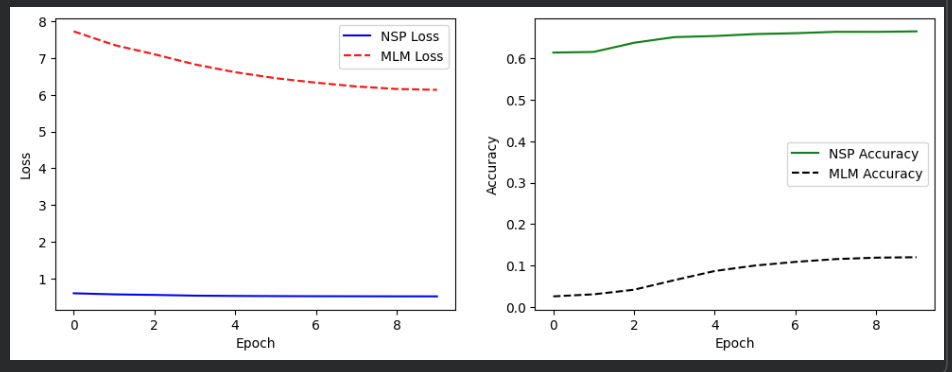  





2M 모델에 비해 거의 반정도로 느리게 개선되는 모습이 확인된다.

이 둘의 차이를 봤을 때 수렴하는 것으로 해석할 수도 있을 것이다.  

---



In [34]:
import torch

# 테스트할 문장: [MASK]를 하나씩 넣어 주세요.
test_sentences = [
    "대한민국의 수도는 [MASK]이다.",
    "일본의 수도는 [MASK]이다.",
    "치킨은 [MASK]다.",
    "나는 학교에서 [MASK]를 공부한다.",
    "겨울에는 날씨가 [MASK].",
]

chat_model = pre_train_model
chat_device = next(chat_model.parameters()).device
chat_model.eval()

cls_id = vocab.piece_to_id("[CLS]")
sep_id = vocab.piece_to_id("[SEP]")
mask_id = vocab.piece_to_id("[MASK]")
max_length = chat_model.bert.position.embedding.num_embeddings

for number, text in enumerate(test_sentences, 1):
    print(f"\n{'=' * 60}")
    print(f"테스트 {number}: {text}")

    if text.count("[MASK]") != 1:
        print("건너뜀: [MASK]를 정확히 하나 넣어 주세요.")
        continue

    # 문장 전체를 한 번에 토크나이징
    sentence_ids = vocab.encode_as_ids(text)

    if sentence_ids.count(mask_id) != 1:
        print("건너뜀: [MASK]가 특수 토큰으로 인식되지 않았습니다.")
        continue

    token_ids = [cls_id] + sentence_ids + [sep_id]

    if len(token_ids) > max_length:
        print(f"건너뜀: 최대 입력 길이 {max_length}토큰을 초과했습니다.")
        continue

    inputs = torch.tensor(
        [token_ids], dtype=torch.long, device=chat_device
    )
    segments = torch.zeros_like(inputs)
    mask_position = token_ids.index(mask_id)

    with torch.no_grad():
        _, logits_mlm = chat_model(inputs, segments)
        scores = logits_mlm[0, mask_position].clone()

        # 현재 토크나이저의 특수 토큰 7개 제외
        scores[:7] = -float("inf")
        top_ids = scores.topk(5).indices.tolist()

    for rank, token_id in enumerate(top_ids, 1):
        completed_ids = sentence_ids.copy()
        completed_ids[mask_position - 1] = token_id

        completed_text = vocab.decode_ids(completed_ids)
        token = vocab.id_to_piece(token_id)

        print(f"  {rank}. {completed_text}  (토큰: {token})")


테스트 1: 대한민국의 수도는 [MASK]이다.
  1. 대한민국의 수도는  다음을이다.  (토큰: ▁다음을)
  2. 대한민국의 수도는  다른이다.  (토큰: ▁다른)
  3. 대한민국의 수도는  다음이다.  (토큰: ▁다음)
  4. 대한민국의 수도는  뜻은이다.  (토큰: ▁뜻은)
  5. 대한민국의 수도는  다음과이다.  (토큰: ▁다음과)

테스트 2: 일본의 수도는 [MASK]이다.
  1. 일본의 수도는  다음을이다.  (토큰: ▁다음을)
  2. 일본의 수도는  다른이다.  (토큰: ▁다른)
  3. 일본의 수도는  다음이다.  (토큰: ▁다음)
  4. 일본의 수도는  뜻은이다.  (토큰: ▁뜻은)
  5. 일본의 수도는  다음과이다.  (토큰: ▁다음과)

테스트 3: 치킨은 [MASK]다.
  1. 치킨은  뜻은다.  (토큰: ▁뜻은)
  2. 치킨은  다른다.  (토큰: ▁다른)
  3. 치킨은  다음다.  (토큰: ▁다음)
  4. 치킨은  다음을다.  (토큰: ▁다음을)
  5. 치킨은  다음과다.  (토큰: ▁다음과)

테스트 4: 나는 학교에서 [MASK]를 공부한다.
  1. 나는 학교에서  다른를 공부한다.  (토큰: ▁다른)
  2. 나는 학교에서  같은를 공부한다.  (토큰: ▁같은)
  3. 나는 학교에서  다음를 공부한다.  (토큰: ▁다음)
  4. 나는 학교에서  다음과를 공부한다.  (토큰: ▁다음과)
  5. 나는 학교에서  뜻은를 공부한다.  (토큰: ▁뜻은)

테스트 5: 겨울에는 날씨가 [MASK].
  1. 겨울에는 날씨가  다른.  (토큰: ▁다른)
  2. 겨울에는 날씨가  뜻은.  (토큰: ▁뜻은)
  3. 겨울에는 날씨가  다음.  (토큰: ▁다음)
  4. 겨울에는 날씨가  다음과.  (토큰: ▁다음과)
  5. 겨울에는 날씨가  다음을.  (토큰: ▁다음을)


## 루브릭

- BERT pretrain 데이터셋이 지시대로 구축되었다.
    - SentencePiece 토크나이저 준비, MLM 마스킹(15%, 어절 단위·80/10/10 규칙), NSP 쌍 생성과 segment 처리를 거쳐 json 데이터셋이 만들어졌다.
- mini BERT 모델이 정상적으로 구동된다.
    - Transformer encoder 기반 BERT 와 pretrain 용 모델(MLM·NSP 헤드)이 구현되어 학습이 오류 없이 진행된다.
- pretrain 결과가 시각화되고 해석되었다.
    - MLM·NSP 의 loss 와 accuracy 곡선이 제시되고, 수렴 여부와 모델 크기·학습 시간 사이의 관계에 대한 고찰이 있다.